## Will Paz

In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import svd
import matplotlib.pyplot as plt
import helper_ahmad as mad

In [2]:
rawdf = pd.read_csv('ahmad_pca.csv')

In [3]:
columns = ['player_name','spin_rate','velocity','release_extension',
           'release_pos_z','release_pos_x','pitcher_break_z_induced',
          'pitcher_break_x']
rawdf = rawdf.loc[:,columns]

In [4]:
rawdf # Raw dataframe

,player_name,spin_rate,velocity,release_extension,release_pos_z,release_pos_x,pitcher_break_z_induced,pitcher_break_x
0,"Vesia, Alex",2399.000000,93.4,6.390000,5.850000,0.530000,20.300000,6.200000
1,"Javier, Cristian",2301.000000,91.7,6.000000,5.780000,1.410000,20.000000,5.800000
2,"Pivetta, Nick",2311.000000,93.9,6.830000,6.840000,1.450000,19.900000,4.000000
3,"Matsui, Yuki",2439.000000,92.2,5.950000,6.010000,2.010000,19.800000,4.300000
4,"McKenzie, Triston",2229.000000,91.1,6.830000,6.480000,1.640000,19.700000,1.600000
...,...,...,...,...,...,...,...,...
412,"Thompson, Ryan",2183.000000,92.5,6.890000,4.070000,3.550000,7.100000,11.700000
413,"Milner, Hoby",2017.000000,88.8,6.810000,4.370000,4.120000,7.100000,15.100000
414,"Blach, Ty",2016.000000,89.1,5.150000,5.730000,2.990000,6.000000,13.100000
415,"Hill, Tim",2157.000000,90.7,6.870000,3.400000,3.710000,4.100000,17.600000


In [5]:
normdf = rawdf.copy()

In [6]:
A = np.array(normdf.iloc[:,1:]) 
A = (A - np.mean(A,axis=0)) 
normdf.iloc[:,1:] = A 

In [7]:
normdf # Normalized dataframe

,player_name,spin_rate,velocity,release_extension,release_pos_z,release_pos_x,pitcher_break_z_induced,pitcher_break_x
0,"Vesia, Alex",113.688552,-0.828537,-0.087315,0.034825,-1.354196,4.989125,-1.602273
1,"Javier, Cristian",15.688552,-2.528537,-0.477315,-0.035175,-0.474196,4.689125,-2.002273
2,"Pivetta, Nick",25.688552,-0.328537,0.352685,1.024825,-0.434196,4.589125,-3.802273
3,"Matsui, Yuki",153.688552,-2.028537,-0.527315,0.194825,0.125804,4.489125,-3.502273
4,"McKenzie, Triston",-56.311448,-3.128537,0.352685,0.664825,-0.244196,4.389125,-6.202273
...,...,...,...,...,...,...,...,...
412,"Thompson, Ryan",-102.311448,-1.728537,0.412685,-1.745175,1.665804,-8.210875,3.897727
413,"Milner, Hoby",-268.311448,-5.428537,0.332685,-1.445175,2.235804,-8.210875,7.297727
414,"Blach, Ty",-269.311448,-5.128537,-1.327315,-0.085175,1.105804,-9.310875,5.297727
415,"Hill, Tim",-128.311448,-3.528537,0.392685,-2.415175,1.825804,-11.210875,9.797727


In [8]:
U,S,V = svd(A, full_matrices=False) # SVD decomp

In [9]:
S

array([2917.37458096,   69.74173385,   48.50991739,   40.37232158,
         12.36725441,    8.68710626,    6.42613944])

In [10]:
S[0]**2/sum(S**2) # The percent of the variance accountable by PC1

0.9989299822356806

In [11]:
(S[0]**2 + S[1]**2)/sum(S**2) # The percent of the variance accountable by PC1 and PC2

0.9995008508143133

In [12]:
V # Row 0 is PC1, columns are correspondent to O-Swing%,...

array([[-9.99976522e-01, -4.47811413e-03,  2.60705460e-04,
         1.15192111e-04,  9.68002075e-06, -3.99890101e-03,
         3.29085606e-03],
       [ 4.05399310e-03,  1.01277800e-01, -1.19285079e-02,
        -7.11793508e-02,  9.92658138e-02, -3.79850846e-01,
         9.11250359e-01],
       [ 4.96757562e-03, -6.53918868e-01, -7.02016510e-03,
        -6.80724823e-02,  9.55350465e-02, -7.08316052e-01,
        -2.38419204e-01],
       [ 2.11890518e-03, -7.48170149e-01, -1.85392598e-02,
         2.45641274e-02, -1.59811801e-02,  5.76385604e-01,
         3.26824227e-01],
       [-8.66868581e-04,  3.98911135e-02,  1.75828285e-01,
        -1.51472318e-01,  9.61231935e-01,  1.27660648e-01,
        -6.54555213e-02],
       [-1.90481960e-04,  1.50052909e-02, -8.49687841e-01,
         4.73331161e-01,  2.31100733e-01, -1.70291838e-02,
        -8.08996790e-03],
       [-7.52733714e-04,  2.31912945e-02, -4.96567863e-01,
        -8.61806229e-01, -5.82200453e-02,  7.19591222e-02,
        -4.0053580

#### Regarding the first principle component, we can see that players who have a low O-Contact%, relative to moderate levels of O-Swing% and Z-Swing%, or vice versa will be accountable for approximately 66.8% of the variance. Using a basline of being a value of .25 in either direction of the origin as the bounds to be not an outlier, we were able to label the outliers in the figure below. Out of the outlined 3 outliers, the most extreme examples in either direction of the first principle component are Jose Fernandez and Bartolo Colon. Before his unfortunate death in 2016, Fernandez put together a phenomal season where he was named an all star and placed top 10 in Cy Young voting. It may be attributed to the qualitative nature of our study where his success stems from having such a low O-Contact% meaning he was unhittable on a batter's swing outside of the zone. In his age 43 season, Colon did the opposite of Fernandez and was hit around more than anyone else on pitches outside of the zone.

#### Regarding the second principle component, as the Z-Swing% of a player is high and the Z-Contact% is low or vice versa, this compiled with the first principle component  will be accountable for approximately 83.6% of the variance. Similarly to the first principle component analysis, the outliers were defined by the distance from the origin being either .23 away from the origin in either the horizontal or vertical directions. The specific outliers to consider here are David Price and Doug Fister. In his prime, Price threw a ton a great games in his career and enough to earn him a Cy Young award. In 2016, it's no suprise that Price one of the best at getting swings and misses in the zone, hence having both a high Z-Swing% and a low Z-Contact%, which contexually would yield fruitful results. On the other hand, a journeyman in struggled in 2016 where he exhibited a very low Z-Swing% compared to everyone else, contextually leading us to believe that he struggled to throw strikes for batters to swing at.

In [13]:
PCdf = normdf.copy()

In [14]:
PCdf.iloc[:,1:] = U
PCcols = {'spin_rate':'PC1','velocity':'PC2',
          'release_extension':'PC3','release_pos_z':'PC4','release_pos_x':'PC5'}
PCdf = PCdf.rename(columns=PCcols)

In [15]:
C = np.array(PCdf.iloc[:,1:]) 

In [16]:
PCdf # PC1 column is how a player compares to other players in uncorrelated fashion to other players regarding PC1

,player_name,PC1,PC2,PC3,PC4,PC5,pitcher_break_z_induced,pitcher_break_x
0,"Vesia, Alex",-0.038976,-0.044652,-0.044866,0.080176,-0.057582,-0.037799,0.063893
1,"Javier, Cristian",-0.005382,-0.055019,-0.023751,0.098804,0.006533,0.020116,0.099922
2,"Pivetta, Nick",-0.008815,-0.075384,-0.043605,0.042808,0.023350,0.003206,-0.089865
3,"Matsui, Yuki",-0.052686,-0.064153,-0.005201,0.081708,0.047454,0.053127,0.060254
4,"McKenzie, Triston",0.019293,-0.113848,0.001337,0.067815,0.049881,-0.011766,-0.031087
...,...,...,...,...,...,...,...,...
412,"Thompson, Ryan",0.035087,0.091273,0.119228,-0.060919,0.052925,-0.079415,0.076571
413,"Milner, Hoby",0.091996,0.121194,0.136108,0.026453,0.074122,-0.045998,0.022255
414,"Blach, Ty",0.092337,0.098718,0.153959,-0.009016,-0.053696,0.164967,-0.020275
415,"Hill, Tim",0.044013,0.181492,0.156894,-0.024457,0.007105,-0.111861,0.092702


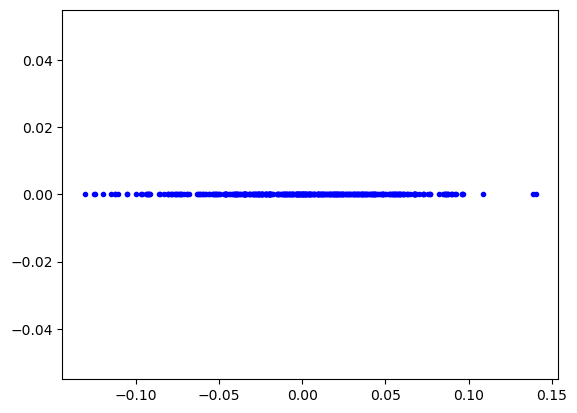

In [17]:
m,n = PCdf.shape

for i in range(m):
    if PCdf['PC1'][i] > 0.25 or PCdf['PC1'][i] < -0.25:
        plt.plot(PCdf['PC1'][i], 0, 'r.')
    else:
        plt.plot(PCdf['PC1'][i], 0,'b.')
        
# 1-D Plot of the PC1

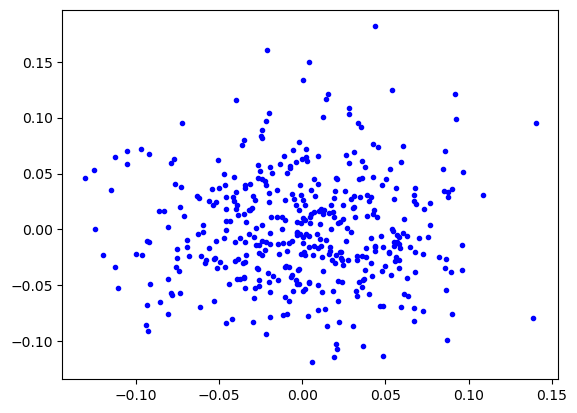

In [18]:
m,n = PCdf.shape

for i in range(m):
    if PCdf['PC1'][i] > 0.23 or PCdf['PC1'][i] < -0.23:
        plt.plot(PCdf['PC1'][i], PCdf['PC2'][i], 'r.')
    elif PCdf['PC2'][i] > 0.23 or PCdf['PC2'][i] < -0.23:
        plt.plot(PCdf['PC1'][i], PCdf['PC2'][i], 'r.')
    else:
        plt.plot(PCdf['PC1'][i], PCdf['PC2'][i], 'b.')
        
# 2-D Plot of the PC1 (x-axis) and PC2 (y-axis)

In [19]:
PCMat_df = mad.dist_mat(PCdf)

In [20]:
PCMat_df # A blank df before we insert the comparisons

,"Vesia, Alex","Javier, Cristian","Pivetta, Nick","Matsui, Yuki","McKenzie, Triston","Richards, Trevor","Anderson, Tyler","Crawford, Kutter","Estrada, Jeremiah","Pepiot, Ryan",...,"Roycroft, Chris","Yarbrough, Ryan","Schreiber, John","Cano, Yennier","Hudson, Dakota","Thompson, Ryan","Milner, Hoby","Blach, Ty","Hill, Tim","Harajli, Ahmad"
"Vesia, Alex",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Javier, Cristian",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Pivetta, Nick",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Matsui, Yuki",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"McKenzie, Triston",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Thompson, Ryan",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Milner, Hoby",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Blach, Ty",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"Hill, Tim",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
def dist_calc(A):
    """
    Calculates the Euclidean squared distance between the rows of A
    Input: An mxn matrix
    Returns: A mxm matrix B where B[i,j] = the Euclidean distance between A[ i , : ] and A[ j , : ]
    """
    m,n = A.shape
    Z = np.zeros([m,m])
    for i in range(m):
        for j in range(m):
            Z[i, j] = np.sum((A[i, :] - A[j, :]) ** 2)
    return Z

In [22]:
B = dist_calc(C)

In [32]:
PCMat_df.iloc[:,0:] = B

In [33]:
comp_df = mad.comp_df(PCdf)

In [34]:
names = PCMat_df.index.values

for i,name in enumerate(names): 
    temp_df = PCMat_df.sort_values(by=name) 
    comps = temp_df.index.values[1:5]
    
    comp_df.iloc[i,:] = comps

In [35]:
comp_df # The comparison dataframe

,Comp1,Comp2,Comp3,Comp4
player_name,,,,
"Vesia, Alex","Knack, Landon","Miller, Bryce","Myers, Tobias","Cortes, Nestor"
"Javier, Cristian","Cortes, Nestor","Suarez, José","Matsui, Yuki","McGough, Scott"
"Pivetta, Nick","Jackson, Luke","Snell, Blake","Wacha, Michael","Woods Richardson, Simeon"
"Matsui, Yuki","Martinez, Nick","Wicks, Jordan","Javier, Cristian","Nastrini, Nick"
"McKenzie, Triston","Poche, Colin","Parker, Mitchell","Kershaw, Clayton","Francis, Bowden"
...,...,...,...,...
"Thompson, Ryan","Schreiber, John","Martinez, Seth","Hill, Tim","Sandlin, Nick"
"Milner, Hoby","Thompson, Ryan","Yarbrough, Ryan","Martinez, Seth","Hill, Tim"
"Blach, Ty","Hudson, Dakota","Hurter, Brant","Morton, Charlie","Yarbrough, Ryan"


In [27]:
print(comp_df.to_string())

                                             Comp1                     Comp2                   Comp3                     Comp4
player_name                                                                                                                   
Vesia, Alex                          Knack, Landon             Miller, Bryce           Myers, Tobias            Cortes, Nestor
Javier, Cristian                    Cortes, Nestor              Suarez, José            Matsui, Yuki            McGough, Scott
Pivetta, Nick                        Jackson, Luke              Snell, Blake          Wacha, Michael  Woods Richardson, Simeon
Matsui, Yuki                        Martinez, Nick             Wicks, Jordan        Javier, Cristian            Nastrini, Nick
McKenzie, Triston                     Poche, Colin          Parker, Mitchell        Kershaw, Clayton           Francis, Bowden
Richards, Trevor                        Lee, Dylan              Kremer, Dean             Ray, Robbie          S